In [2]:
pip install opencv-python numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [19]:
import cv2
import os
import matplotlib as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [11]:
def load_images_and_labels(image_dir):
    images = []
    labels = []
    
    for filename in os.listdir(image_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            label = filename.split('_')[1].split('.')[0]# Extract the label from the filename
            image_path = os.path.join(image_dir, filename)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if image is not None:
                images.append(image)
                labels.append(label)
    
    print(f'Loaded {len(images)} images from {image_dir}')
    return images, labels
data_dir = 'C:/Users/kalpa/Desktop/Face recognisaton'
images, labels = load_images_and_labels(data_dir)


Loaded 410 images from C:/Users/kalpa/Desktop/Face recognisaton


In [15]:
def preprocess_data(images, labels, image_size=(100, 100)):
    resized_images = [cv2.resize(image, image_size) for image in images]
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(labels)
    return np.array(resized_images), encoded_labels, label_encoder
resized_images, encoded_labels, label_encoder = preprocess_data(images, labels)
print(f'Shape of resized_images: {resized_images.shape}')
print(f'Shape of encoded_labels: {encoded_labels.shape}')

Shape of resized_images: (410, 100, 100)
Shape of encoded_labels: (410,)


AFTER PREPROCESSING


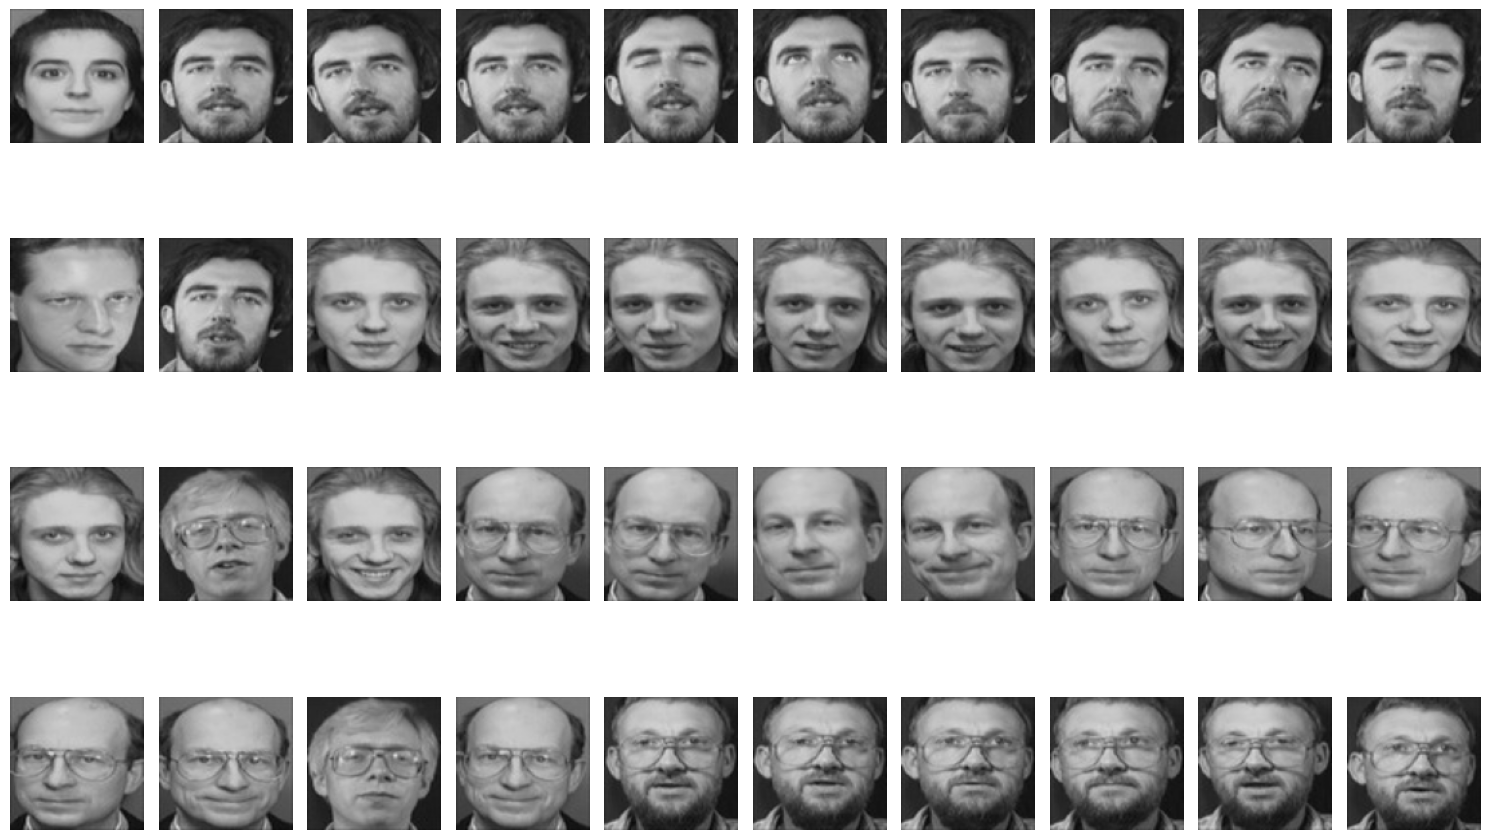

In [41]:
import matplotlib.pyplot as plt
import cv2
print("AFTER PREPROCESSING")
# Define the number of rows and columns
rows, cols = 4, 10

plt.figure(figsize=(15, 10))  # Adjust figure size as needed

for i in range(rows * cols):  
    plt.subplot(rows, cols, i + 1)  
    plt.imshow(cv2.cvtColor(resized_images[i], cv2.COLOR_BGR2RGB))  
    plt.axis('off')  # Hide axes

plt.tight_layout()  # Adjust spacing
plt.show()


In [43]:
X_train, X_test, y_train, y_test = train_test_split(resized_images, encoded_labels, test_size=0.3, random_state=42)
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (287, 100, 100)
Shape of X_test: (123, 100, 100)
Shape of y_train: (287,)
Shape of y_test: (123,)


In [45]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape data
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)  # Add channel dimension
num_classes = len(np.unique(encoded_labels))

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [49]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')  # Number of unique labels
])



C:\Users\kalpa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, batch_size=32,epochs=50,validation_data=(X_test, y_test))

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 390ms/step - accuracy: 0.9589 - loss: 0.2302 - val_accuracy: 0.8130 - val_loss: 0.8233
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - accuracy: 0.9610 - loss: 0.1882 - val_accuracy: 0.8374 - val_loss: 0.7381
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 737ms/step - accuracy: 0.9863 - loss: 0.1398 - val_accuracy: 0.8455 - val_loss: 0.6775
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 530ms/step - accuracy: 0.9805 - loss: 0.1230 - val_accuracy: 0.8862 - val_loss: 0.5719
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 709ms/step - accuracy: 1.0000 - loss: 0.0784 - val_accuracy: 0.8862 - val_loss: 0.5652
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.9959 - loss: 0.0893 - val_accuracy: 0.8943 - val_loss: 0.5351
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.9928 - loss: 0.0693 - val_accuracy: 0.8943 - val_loss: 0.5218
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step - accuracy: 0.9951 - loss: 0.0671 - val_accuracy: 0.9268 - val_loss

In [67]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.9219 - loss: 0.4374
Test Accuracy: 0.934959352016449


4/4 - 1s - 142ms/step - accuracy: 0.9350 - loss: 0.3884


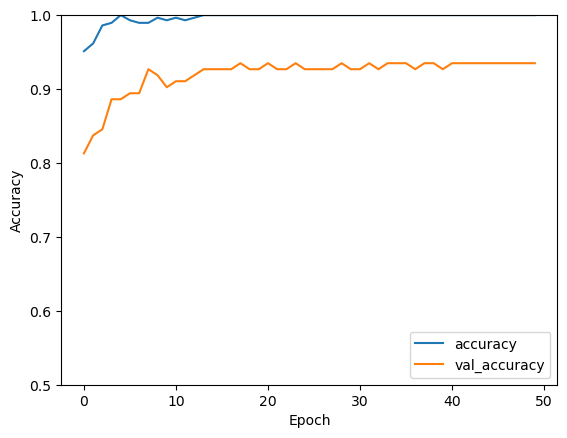

In [69]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

In [71]:
train_loss, train_accuracy = model.evaluate(X_train, y_train)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 1.0000 - loss: 0.0018
Test Accuracy: 0.934959352016449


9/9 - 1s - 162ms/step - accuracy: 0.9861 - loss: 0.1395


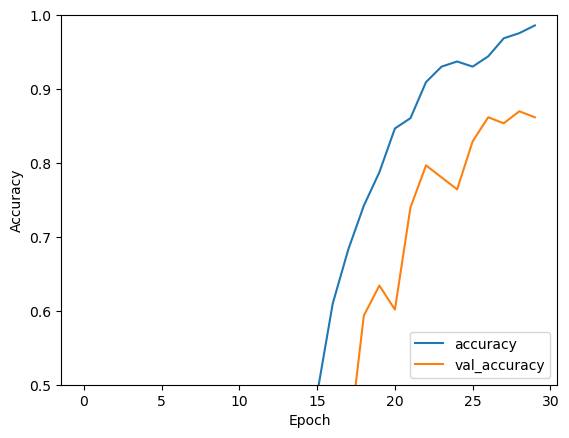

In [58]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_train,  y_train, verbose=2)

In [ ]:
def load_images_and_labels(image_dir):
    images = []
    labels = []
    
    for filename in os.listdir(image_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            label = filename.split('_')[1].split('.')[0]# Extract the label from the filename
            image_path = os.path.join(image_dir, filename)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if image is not None:
                images.append(image)
                labels.append(label)
    
    print(f'Loaded {len(images)} images from {image_dir}')
    return images, labels
data_dir = 'C:/Users/kalpa/Desktop/Face recognisaton'
images, labels = load_images_and_labels(data_dir)
    resized_images = [cv2.resize(image, image_size) for image in images]
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(labels)
    return np.array(resized_images), encoded_labels, label_encoder
resized_images, encoded_labels, label_encoder = preprocess_data(images, labels)
print(f'Shape of resized_images: {resized_images.shape}')
print(f'Shape of encoded_labels: {encoded_labels.shape}')
X_train, X_test, y_train, y_test = train_test_split(resized_images, encoded_labels, test_size=0.3, random_state=42)
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape data
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)  # Add channel dimension
num_classes = len(np.unique(encoded_labels))
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')  # Number of unique labels
])
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, batch_size=32,epochs=30,validation_data=(X_test, y_test))

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)